### 1.- **librerías y rutas**


In [3]:
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

print("Versión de TensorFlow:", tf.__version__)

# Definir las rutas base según tu estructura de directorios
base_dir = './imagenes-satelitales'

# Rutas de entrenamiento y prueba
train_dir = os.path.join(base_dir, 'seg_train/seg_train')
test_dir = os.path.join(base_dir, 'seg_test/seg_test')
pred_dir = os.path.join(base_dir, 'seg_pred/seg_pred')

# Clases del dataset
classes = ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']

print("Rutas configuradas correctamente.")

Versión de TensorFlow: 2.21.0
Rutas configuradas correctamente.


Fase 1 - Análisis Exploratorio (Conteo y Distribución)

--- CONJUNTO DE ENTRENAMIENTO ---
Total de imágenes de buildings: 2191
Total de imágenes de forest: 2271
Total de imágenes de glacier: 2404
Total de imágenes de mountain: 2512
Total de imágenes de sea: 2274
Total de imágenes de street: 2382

--- CONJUNTO DE PRUEBA ---
Total de imágenes de buildings: 437
Total de imágenes de forest: 474
Total de imágenes de glacier: 553
Total de imágenes de mountain: 525
Total de imágenes de sea: 510
Total de imágenes de street: 501

Total general entrenamiento: 14034
Total general prueba: 3000


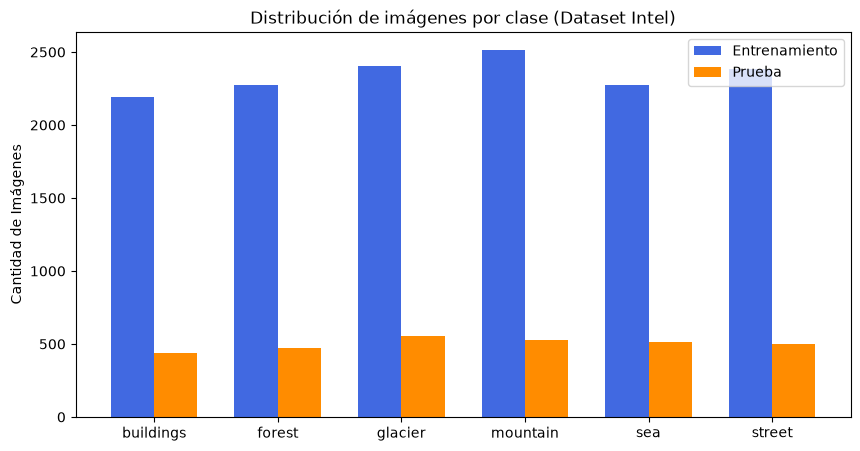

In [4]:
# Diccionarios para almacenar el conteo
train_counts = {}
test_counts = {}

# Contar imágenes en el conjunto de entrenamiento
print("--- CONJUNTO DE ENTRENAMIENTO ---")
for cls in classes:
    path = os.path.join(train_dir, cls)
    count = len(os.listdir(path))
    train_counts[cls] = count
    print(f"Total de imágenes de {cls}: {count}")

# Contar imágenes en el conjunto de prueba
print("\n--- CONJUNTO DE PRUEBA ---")
for cls in classes:
    path = os.path.join(test_dir, cls)
    count = len(os.listdir(path))
    test_counts[cls] = count
    print(f"Total de imágenes de {cls}: {count}")

print(f"\nTotal general entrenamiento: {sum(train_counts.values())}")
print(f"Total general prueba: {sum(test_counts.values())}")

# Graficar la distribución
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(classes))
width = 0.35

ax.bar(x - width/2, list(train_counts.values()), width, label='Entrenamiento', color='royalblue')
ax.bar(x + width/2, list(test_counts.values()), width, label='Prueba', color='darkorange')

ax.set_ylabel('Cantidad de Imágenes')
ax.set_title('Distribución de imágenes por clase (Dataset Intel)')
ax.set_xticks(x)
ax.set_xticklabels(classes)
ax.legend()

plt.show()

Fase 1.1 - Inspección Visual de las Clases

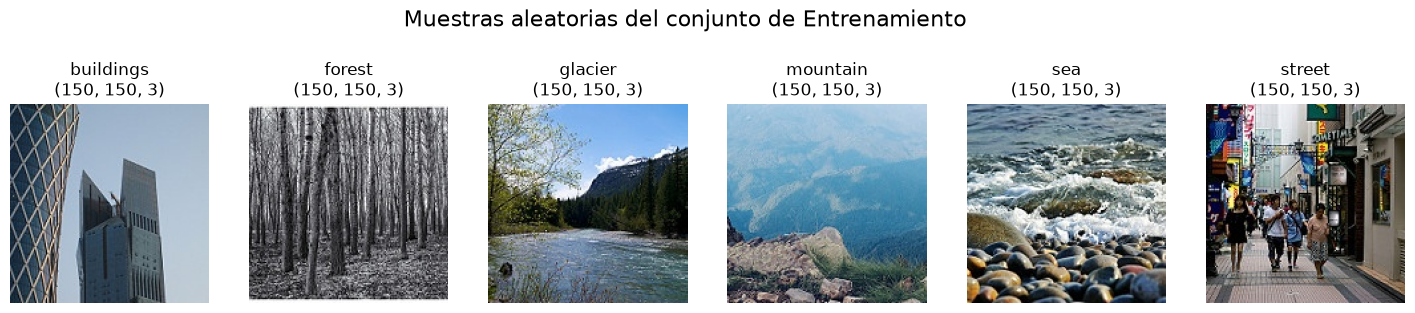

In [5]:
import random

def show_random_samples(directory, classes):
    plt.figure(figsize=(18, 4))
    
    for i, cls in enumerate(classes):
        class_path = os.path.join(directory, cls)
        # Obtener un archivo aleatorio de la clase
        random_image = random.choice(os.listdir(class_path))
        img_path = os.path.join(class_path, random_image)
        
        # Leer y mostrar la imagen
        img = mpimg.imread(img_path)
        plt.subplot(1, len(classes), i + 1)
        plt.imshow(img)
        plt.title(f"{cls}\n{img.shape}")
        plt.axis('off')
        
    plt.suptitle("Muestras aleatorias del conjunto de Entrenamiento", fontsize=16)
    plt.show()

# Ejecutar visualización
show_random_samples(train_dir, classes)

Fase 2 - Preprocesamiento y Data Augmentation

In [6]:
# 1. Configuración de los Generadores (Data Augmentation solo para Train)
train_datagen = ImageDataGenerator(
    rescale=1.0/255.,
    rotation_range=15,       # Rotación aleatoria de +-15 grados
    width_shift_range=0.1,   # Traslación horizontal
    height_shift_range=0.1,  # Traslación vertical
    zoom_range=0.1,          # Zoom aleatorio
    horizontal_flip=True,    # Volteo horizontal aleatorio
    fill_mode='nearest'
)

# Para prueba SOLO reescalamos (no se aumentan los datos de prueba)
test_datagen = ImageDataGenerator(rescale=1.0/255.)

# 2. Carga de imágenes desde los directorios
print("Cargando conjunto de entrenamiento:")
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical' # Categórico porque son 6 clases
)

print("\nCargando conjunto de prueba:")
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical',
    shuffle=False # No mezclar para evaluar matrices de confusión más adelante
)

# Verificar la asignación de índices a clases
print("\nÍndices de las clases asignados por el generador:")
print(train_generator.class_indices)

Cargando conjunto de entrenamiento:
Found 14034 images belonging to 6 classes.

Cargando conjunto de prueba:
Found 3000 images belonging to 6 classes.

Índices de las clases asignados por el generador:
{'buildings': 0, 'forest': 1, 'glacier': 2, 'mountain': 3, 'sea': 4, 'street': 5}


Fase 3 - Definición de la Arquitectura Custom CNN

In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# 1. Definir la arquitectura secuencial
model_custom = Sequential([
    # Primer bloque convolucional
    Conv2D(32, (3,3), activation='relu', input_shape=(150, 150, 3)),
    MaxPooling2D(2, 2),
    
    # Segundo bloque convolucional
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2, 2),
    
    # Tercer bloque convolucional
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2, 2),
    
    # Cuarto bloque convolucional
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2, 2),
    
    # Aplanamiento y capas densas
    Flatten(),
    Dropout(0.5), # Apaga el 50% de las neuronas aleatoriamente para evitar sobreajuste
    Dense(512, activation='relu'),
    
    # Capa de salida: 6 neuronas (por las 6 clases) y activación softmax
    Dense(6, activation='softmax')
])

# Mostrar el resumen de la arquitectura
model_custom.summary()

/mnt/c/Users/USUARIO/OneDrive/Documentos/python/image-scene-classification/wsl_env_312/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 15, 15, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │     3,211,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │         3,078 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,455,686 (13.18 MB)

 Trainable params: 3,455,686 (13.18 MB)

 Non-trainable params: 0 (0.00 B)

Fase 3.1 - Compilación y Callbacks

In [8]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Compilar el modelo
model_custom.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy', # Categórica porque son > 2 clases
    metrics=['accuracy']
)

# Definir los callbacks (parada temprana y guardado del mejor modelo)
callbacks = [
    EarlyStopping(
        monitor='val_loss', 
        patience=5, # Se detiene si no mejora en 5 épocas
        restore_best_weights=True
    ),
    ModelCheckpoint(
        'custom_cnn_best.keras', 
        monitor='val_loss', 
        save_best_only=True,
        verbose=1
    )
]
print("Modelo compilado y callbacks configurados.")

Modelo compilado y callbacks configurados.


Fase 3.2 - Fase "Sin Transfer Learning" (VGG16 desde cero)

Esta celda descarga la estructura de VGG16, pero completamente "en blanco" (weights=None), y la entrena directamente con tus imágenes.

In [ ]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
import matplotlib.pyplot as plt

print("Cargando VGG16 SIN Transfer Learning (Desde cero)...")

# 1. Cargar VGG16 pero con weights=None (sin conocimiento previo)
base_model_scratch = VGG16(
    weights=None, 
    include_top=False, 
    input_shape=(150, 150, 3)
)

# NO congelamos nada, queremos que toda la red aprenda desde cero
base_model_scratch.trainable = True 

# 2. Construir el modelo secuencial (usando un nombre nuevo: model_vgg_scratch)
model_vgg_scratch = Sequential([
    base_model_scratch,
    GlobalAveragePooling2D(),
    Dropout(0.5),
    Dense(6, activation='softmax')
])

# 3. Compilar el modelo
model_vgg_scratch.compile(
    optimizer=Adam(learning_rate=1e-4), # Tasa estándar para aprender desde cero
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 4. Callbacks con un nombre de archivo distinto para no sobrescribir el otro
callbacks_scratch = [
    EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True),
    ModelCheckpoint('vgg16_scratch_best.keras', monitor='val_loss', save_best_only=True, verbose=1)
]

print("Iniciando entrenamiento de VGG16 Sin Transfer Learning...")

# 5. Entrenamiento
history_scratch = model_vgg_scratch.fit(
    train_generator,
    epochs=20,
    validation_data=test_generator,
    callbacks=callbacks_scratch,
    verbose=1
)
print("¡Entrenamiento finalizado!")

Cargando VGG16 SIN Transfer Learning (Desde cero)...
Iniciando entrenamiento de VGG16 Sin Transfer Learning...
Epoch 1/30
380/439 ━━━━━━━━━━━━━━━━━━━━ 6:19 6s/step - accuracy: 0.4751 - loss: 1.2562

KeyboardInterrupt: 

Fase 3.3 - Gráficas de Rendimiento

curvas de entrenamiento (precisión y pérdida). gráficas comparando cómo aprendió el modelo vs cómo le fue con los datos de validación.

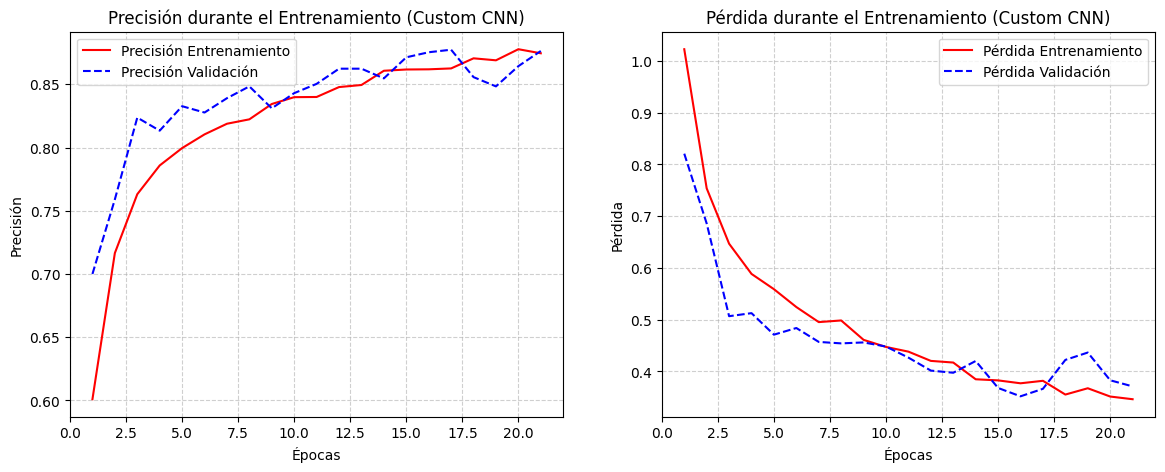

In [10]:
# Extraer datos del historial
acc = history_custom.history['accuracy']
val_acc = history_custom.history['val_accuracy']
loss = history_custom.history['loss']
val_loss = history_custom.history['val_loss']
epochs_range = range(1, len(acc) + 1)

# Crear la figura
plt.figure(figsize=(14, 5))

# Gráfica de Precisión (Accuracy)
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, 'r-', label='Precisión Entrenamiento')
plt.plot(epochs_range, val_acc, 'b--', label='Precisión Validación')
plt.title('Precisión durante el Entrenamiento (Custom CNN)')
plt.xlabel('Épocas')
plt.ylabel('Precisión')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Gráfica de Pérdida (Loss)
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, 'r-', label='Pérdida Entrenamiento')
plt.plot(epochs_range, val_loss, 'b--', label='Pérdida Validación')
plt.title('Pérdida durante el Entrenamiento (Custom CNN)')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

Fase 4 - Carga del Modelo Base (VGG16) y Congelamiento

In [11]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout

print("Cargando el modelo base VGG16...")

# 1. Cargar el modelo base preentrenado (excluyendo la capa superior)
base_model_vgg = VGG16(
    weights='imagenet', 
    include_top=False, 
    input_shape=(150, 150, 3)
)

# 2. Congelar todas las capas convolucionales base
base_model_vgg.trainable = False

print("Modelo base cargado y capas congeladas.")
# Opcional: ver cuántas capas tiene el modelo base
print(f"Número de capas en el modelo base: {len(base_model_vgg.layers)}")

Cargando el modelo base VGG16...
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Modelo base cargado y capas congeladas.
Número de capas en el modelo base: 19


Fase 4 - Construcción y Compilación de la Nueva Arquitectura

In [12]:
from tensorflow.keras.optimizers import Adam

# 3. Construir el nuevo modelo secuencial
model_vgg = Sequential([
    base_model_vgg,
    GlobalAveragePooling2D(),
    Dropout(0.5), # Añadimos Dropout para prevenir sobreajuste
    Dense(6, activation='softmax') # 6 neuronas para nuestras 6 clases de paisajes
])

# 4. Compilar el modelo
# Usamos un learning rate de 1e-4 como se especificó en tu Tabla 1
model_vgg.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_vgg.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │         3,078 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,717,766 (56.14 MB)

 Trainable params: 3,078 (12.02 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

Fase 4.2 - Entrenamiento (Feature Extraction)

Ejecutamos el entrenamiento por 15 épocas. la red no está actualizando los pesos de las capas convolucionales, solo está entrenando la capa final.

VGG16

In [14]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# Configuramos callbacks específicos para VGG16
callbacks_vgg = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ModelCheckpoint('vgg16_feature_extraction_best.keras', monitor='val_loss', save_best_only=True, verbose=1)
]

print("Iniciando entrenamiento con Transfer Learning (Extracción de características)...")

history_vgg = model_vgg.fit(
    train_generator,
    epochs=15, # Según la Tabla 1 de tu artículo
    validation_data=test_generator,
    callbacks=callbacks_vgg,
    verbose=1
)

print("¡Entrenamiento VGG16 finalizado!")

Iniciando entrenamiento con Transfer Learning (Extracción de características)...
Epoch 1/15
439/439 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.4352 - loss: 1.4457
Epoch 1: val_loss improved from None to 1.25826, saving model to vgg16_feature_extraction_best.keras

Epoch 1: finished saving model to vgg16_feature_extraction_best.keras
439/439 ━━━━━━━━━━━━━━━━━━━━ 1509s 3s/step - accuracy: 0.4352 - loss: 1.4457 - val_accuracy: 0.6977 - val_loss: 1.2583
Epoch 2/15
439/439 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5530 - loss: 1.2577
Epoch 2: val_loss improved from 1.25826 to 1.10674, saving model to vgg16_feature_extraction_best.keras

Epoch 2: finished saving model to vgg16_feature_extraction_best.keras
439/439 ━━━━━━━━━━━━━━━━━━━━ 568s 1s/step - accuracy: 0.5530 - loss: 1.2577 - val_accuracy: 0.7370 - val_loss: 1.1067
Epoch 3/15
439/439 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6159 - loss: 1.1319
Epoch 3: val_loss improved from 1.10674 to 1.00077, saving model to vgg16_featur

Gráficas de Rendimiento (VGG16)

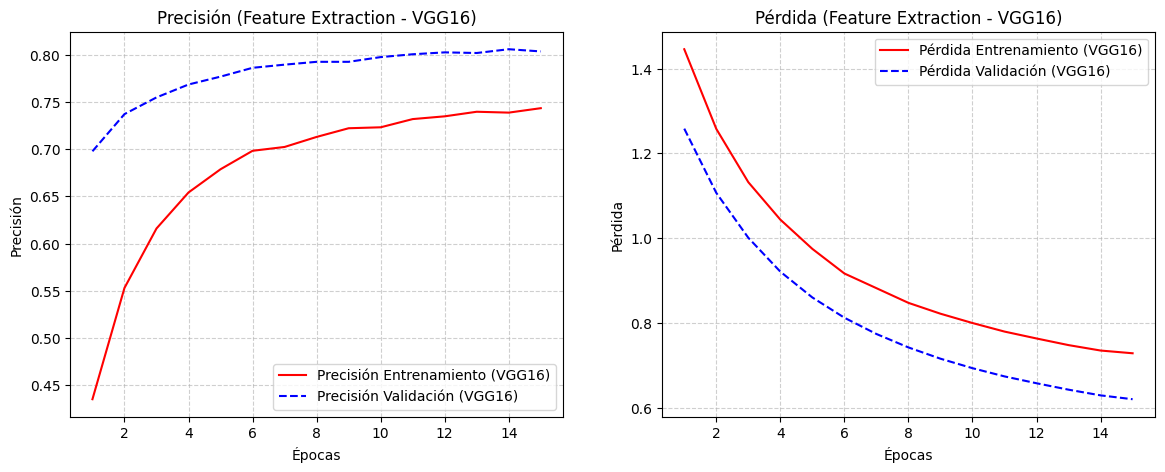

In [15]:
# Extraer datos del historial
acc_vgg = history_vgg.history['accuracy']
val_acc_vgg = history_vgg.history['val_accuracy']
loss_vgg = history_vgg.history['loss']
val_loss_vgg = history_vgg.history['val_loss']
epochs_vgg = range(1, len(acc_vgg) + 1)

# Crear la figura
plt.figure(figsize=(14, 5))

# Gráfica de Precisión
plt.subplot(1, 2, 1)
plt.plot(epochs_vgg, acc_vgg, 'r-', label='Precisión Entrenamiento (VGG16)')
plt.plot(epochs_vgg, val_acc_vgg, 'b--', label='Precisión Validación (VGG16)')
plt.title('Precisión (Feature Extraction - VGG16)')
plt.xlabel('Épocas')
plt.ylabel('Precisión')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Gráfica de Pérdida
plt.subplot(1, 2, 2)
plt.plot(epochs_vgg, loss_vgg, 'r-', label='Pérdida Entrenamiento (VGG16)')
plt.plot(epochs_vgg, val_loss_vgg, 'b--', label='Pérdida Validación (VGG16)')
plt.title('Pérdida (Feature Extraction - VGG16)')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

Descongelar las últimas capas de VGG16

In [16]:
print("Preparando el modelo para Fine-Tuning...")

# 1. Descongelar el modelo base completo temporalmente
base_model_vgg.trainable = True

# 2. Volver a congelar todas las capas EXCEPTO el último bloque convolucional (block5)
set_trainable = False
for layer in base_model_vgg.layers:
    if layer.name == 'block5_conv1':
        set_trainable = True
        
    if set_trainable:
        layer.trainable = True
    else:
        layer.trainable = False

# Comprobar cuántas capas son entrenables ahora
trainable_layers = [layer.name for layer in base_model_vgg.layers if layer.trainable]
print(f"Capas descongeladas para Fine-Tuning: {trainable_layers}")

Preparando el modelo para Fine-Tuning...
Capas descongeladas para Fine-Tuning: ['block5_conv1', 'block5_conv2', 'block5_conv3', 'block5_pool']


Re-compilación con Tasa de Aprendizaje Baja

In [17]:
from tensorflow.keras.optimizers import Adam

# Re-compilar el modelo con un learning rate muy bajo (1e-5)
model_vgg.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_vgg.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │         3,078 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,717,766 (56.14 MB)

 Trainable params: 7,082,502 (27.02 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

Entrenamiento de Ajuste Fino

In [28]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# Configuramos nuevos callbacks para guardar este modelo específico
callbacks_finetuning = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ModelCheckpoint('vgg16_finetuning_best.keras', monitor='val_loss', save_best_only=True, verbose=1)
]

print("Iniciando entrenamiento de Fine-Tuning...")

# Entrenamos por otras 15 épocas
history_finetuning = model_vgg.fit(
    train_generator,
    epochs=15, # Según la Tabla 1 de tu artículo
    validation_data=test_generator,
    callbacks=callbacks_finetuning,
    verbose=1
)

print("¡Fine-Tuning con VGG16 finalizado!")

Iniciando entrenamiento de Fine-Tuning...
Epoch 1/15
439/439 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8600 - loss: 0.3861
Epoch 1: val_loss improved from None to 0.32074, saving model to vgg16_finetuning_best.keras

Epoch 1: finished saving model to vgg16_finetuning_best.keras
439/439 ━━━━━━━━━━━━━━━━━━━━ 568s 1s/step - accuracy: 0.8600 - loss: 0.3861 - val_accuracy: 0.8733 - val_loss: 0.3207
Epoch 2/15
439/439 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8773 - loss: 0.3390
Epoch 2: val_loss improved from 0.32074 to 0.28720, saving model to vgg16_finetuning_best.keras

Epoch 2: finished saving model to vgg16_finetuning_best.keras
439/439 ━━━━━━━━━━━━━━━━━━━━ 572s 1s/step - accuracy: 0.8773 - loss: 0.3390 - val_accuracy: 0.8907 - val_loss: 0.2872
Epoch 3/15
439/439 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8893 - loss: 0.3114
Epoch 3: val_loss improved from 0.28720 to 0.26982, saving model to vgg16_finetuning_best.keras

Epoch 3: finished saving model to vgg16_finetuning_best

Gráficas de Rendimiento (Fine-Tuning)

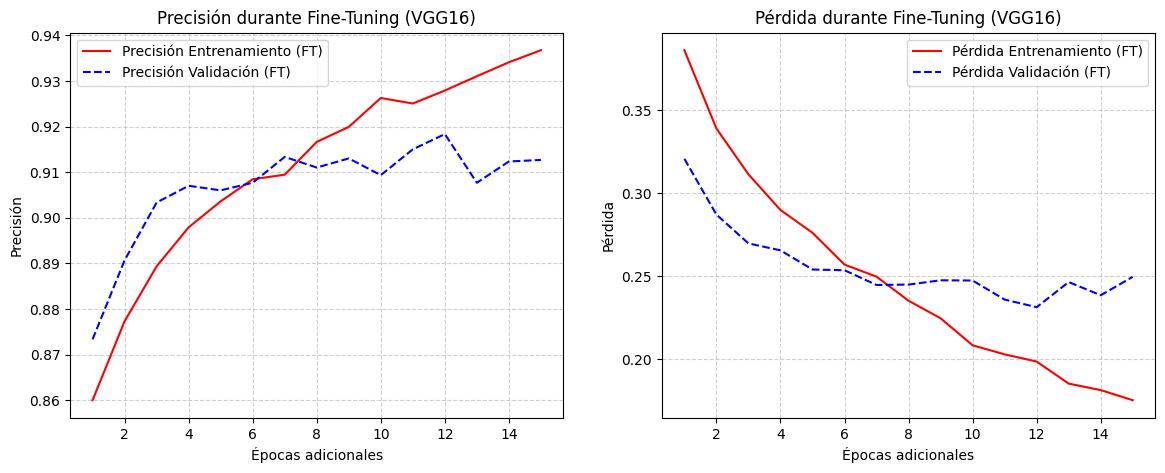

In [29]:
# Extraer datos del historial de fine-tuning
acc_ft = history_finetuning.history['accuracy']
val_acc_ft = history_finetuning.history['val_accuracy']
loss_ft = history_finetuning.history['loss']
val_loss_ft = history_finetuning.history['val_loss']
epochs_ft = range(1, len(acc_ft) + 1)

# Crear la figura
plt.figure(figsize=(14, 5))

# Gráfica de Precisión
plt.subplot(1, 2, 1)
plt.plot(epochs_ft, acc_ft, 'r-', label='Precisión Entrenamiento (FT)')
plt.plot(epochs_ft, val_acc_ft, 'b--', label='Precisión Validación (FT)')
plt.title('Precisión durante Fine-Tuning (VGG16)')
plt.xlabel('Épocas adicionales')
plt.ylabel('Precisión')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Gráfica de Pérdida
plt.subplot(1, 2, 2)
plt.plot(epochs_ft, loss_ft, 'r-', label='Pérdida Entrenamiento (FT)')
plt.plot(epochs_ft, val_loss_ft, 'b--', label='Pérdida Validación (FT)')
plt.title('Pérdida durante Fine-Tuning (VGG16)')
plt.xlabel('Épocas adicionales')
plt.ylabel('Pérdida')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

Fase 6 - Predicciones y Reporte de Clasificación (Métricas)
Esta celda evaluará el modelo con los datos de prueba y calculará la exactitud (Accuracy), Precisión, Exhaustividad (Recall) y el F1-Score promedio macro.

In [31]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

print("Evaluando el modelo Fine-Tuned en el conjunto de prueba...")

# 1. Asegurarnos de que el generador empiece desde el principio
test_generator.reset()

# 2. Obtener las predicciones del modelo
# Esto devolverá las probabilidades para cada clase
Y_pred = model_vgg.predict(test_generator, verbose=1)

# 3. Convertir las probabilidades a la clase con mayor probabilidad
y_pred = np.argmax(Y_pred, axis=1)

# 4. Obtener las etiquetas reales
y_true = test_generator.classes

# 5. Obtener los nombres de las clases directamente del generador
nombres_clases = list(test_generator.class_indices.keys())

# 6. Imprimir el reporte completo de métricas
print("\n" + "="*50)
print("REPORTE DE CLASIFICACIÓN (MÉTRICAS)")
print("="*50)
reporte = classification_report(y_true, y_pred, target_names=nombres_clases, digits=4)
print(reporte)

Evaluando el modelo Fine-Tuned en el conjunto de prueba...
94/94 ━━━━━━━━━━━━━━━━━━━━ 111s 1s/step

REPORTE DE CLASIFICACIÓN (MÉTRICAS)
              precision    recall  f1-score   support

   buildings     0.9437    0.9199    0.9316       437
      forest     0.9853    0.9916    0.9884       474
     glacier     0.8456    0.8716    0.8584       553
    mountain     0.8748    0.8648    0.8697       525
         sea     0.9553    0.9216    0.9381       510
      street     0.9244    0.9521    0.9381       501

    accuracy                         0.9183      3000
   macro avg     0.9215    0.9203    0.9207      3000
weighted avg     0.9189    0.9183    0.9185      3000



8: Fase 6 - Generación de la Matriz de Confusión
Esta celda creará el mapa de calor (heatmap) para visualizar exactamente dónde se está confundiendo el modelo (por ejemplo, cuántas veces predijo "montaña" cuando en realidad era "glaciar").

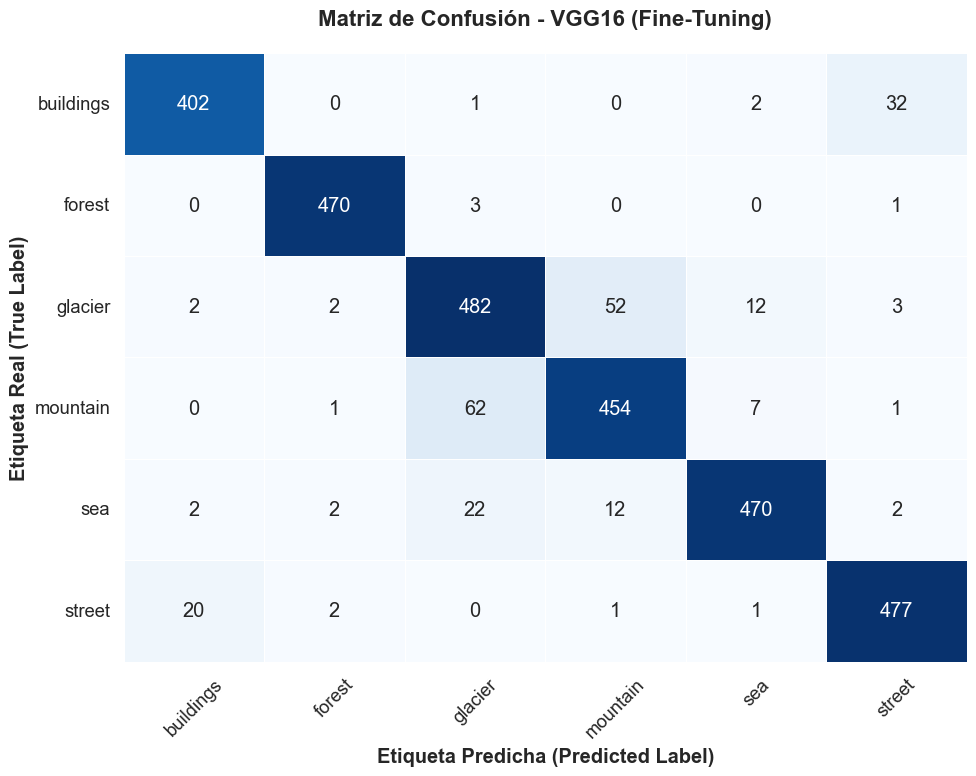

In [33]:
import seaborn as sns

# 1. Calcular la matriz de confusión
cm = confusion_matrix(y_true, y_pred)

# 2. Configurar el tamaño y estilo de la figura para el artículo
plt.figure(figsize=(10, 8))
sns.set(font_scale=1.2) # Tamaño de fuente para que sea legible en el paper

# 3. Crear el Heatmap (Mapa de calor)
heatmap = sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', # Formato de número entero (d)
    cmap='Blues', # Escala de colores azules (muy formal para papers)
    xticklabels=nombres_clases, 
    yticklabels=nombres_clases,
    linewidths=.5,
    cbar=False
)

# 4. Añadir etiquetas y título
plt.ylabel('Etiqueta Real (True Label)', fontweight='bold')
plt.xlabel('Etiqueta Predicha (Predicted Label)', fontweight='bold')
plt.title('Matriz de Confusión - VGG16 (Fine-Tuning)', fontsize=16, fontweight='bold', pad=20)

# Rotar las etiquetas del eje X para mejor lectura
plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

ResNet50 Sin Transfer Learning (Desde Cero)

In [11]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
import matplotlib.pyplot as plt
import os
os.environ['TF_GPU_ALLOCATOR'] = 'cuda_malloc_async'

print("Cargando ResNet50 SIN Transfer Learning (Desde cero)...")

# 1. Cargar ResNet50 en blanco (weights=None)
base_model_resnet_scratch = ResNet50(
    weights=None, 
    include_top=False, 
    input_shape=(150, 150, 3)
)

# Queremos que toda la red aprenda desde cero
base_model_resnet_scratch.trainable = True 

# 2. Construir el modelo
model_resnet_scratch = Sequential([
    base_model_resnet_scratch,
    GlobalAveragePooling2D(),
    Dropout(0.5),
    Dense(6, activation='softmax')
])

# 3. Compilar
model_resnet_scratch.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 4. Callbacks
callbacks_resnet_scratch = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ModelCheckpoint('resnet50_scratch_best.keras', monitor='val_loss', save_best_only=True, verbose=1)
]

print("Iniciando entrenamiento de ResNet50 Sin Transfer Learning...")

# 5. Entrenamiento
history_resnet_scratch = model_resnet_scratch.fit(
    train_generator,
    epochs=20,
    validation_data=test_generator,
    callbacks=callbacks_resnet_scratch,
    verbose=1
)
print("¡Entrenamiento finalizado!")

Cargando ResNet50 SIN Transfer Learning (Desde cero)...
Iniciando entrenamiento de ResNet50 Sin Transfer Learning...
Epoch 1/20


I0000 00:00:1784691854.373019   59829 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_95532__.397


231/439 ━━━━━━━━━━━━━━━━━━━━ 2:20 677ms/step - accuracy: 0.3971 - loss: 1.9072

I0000 00:00:1784692036.961869   59828 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_95532__.397


439/439 ━━━━━━━━━━━━━━━━━━━━ 0s 676ms/step - accuracy: 0.4634 - loss: 1.6710
Epoch 1: val_loss improved from None to 2.89198, saving model to resnet50_scratch_best.keras

Epoch 1: finished saving model to resnet50_scratch_best.keras
439/439 ━━━━━━━━━━━━━━━━━━━━ 432s 836ms/step - accuracy: 0.4634 - loss: 1.6710 - val_accuracy: 0.2890 - val_loss: 2.8920
Epoch 2/20
439/439 ━━━━━━━━━━━━━━━━━━━━ 0s 425ms/step - accuracy: 0.6112 - loss: 1.1325
Epoch 2: val_loss improved from 2.89198 to 1.89083, saving model to resnet50_scratch_best.keras

Epoch 2: finished saving model to resnet50_scratch_best.keras
439/439 ━━━━━━━━━━━━━━━━━━━━ 210s 477ms/step - accuracy: 0.6112 - loss: 1.1325 - val_accuracy: 0.4510 - val_loss: 1.8908
Epoch 3/20
439/439 ━━━━━━━━━━━━━━━━━━━━ 0s 425ms/step - accuracy: 0.6832 - loss: 0.8533
Epoch 3: val_loss improved from 1.89083 to 1.07158, saving model to resnet50_scratch_best.keras

Epoch 3: finished saving model to resnet50_scratch_best.keras
439/439 ━━━━━━━━━━━━━━━━━━━━ 23

Gráficas de ResNet50 (Desde Cero)

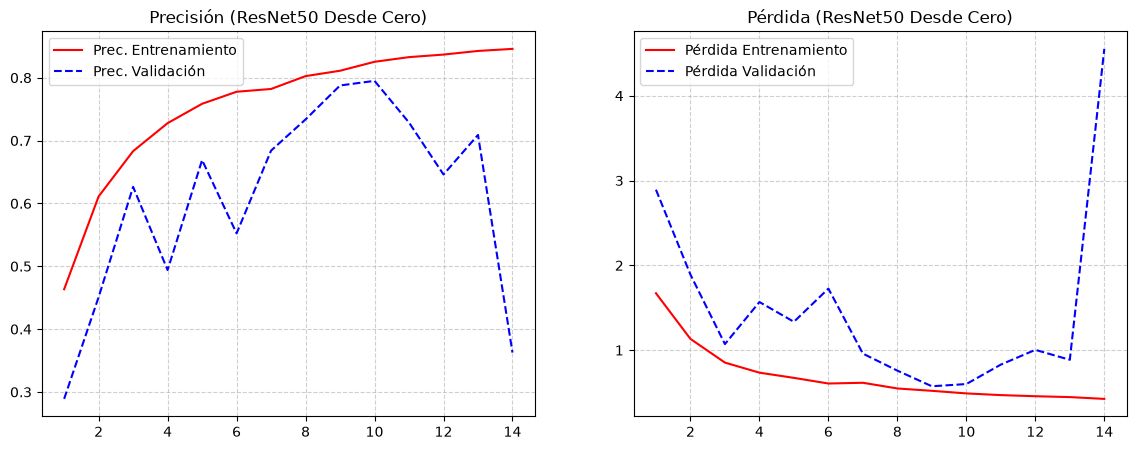

In [12]:
# Extraer datos
acc = history_resnet_scratch.history['accuracy']
val_acc = history_resnet_scratch.history['val_accuracy']
loss = history_resnet_scratch.history['loss']
val_loss = history_resnet_scratch.history['val_loss']
epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(14, 5))

# Precisión
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, 'r-', label='Prec. Entrenamiento')
plt.plot(epochs_range, val_acc, 'b--', label='Prec. Validación')
plt.title('Precisión (ResNet50 Desde Cero)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Pérdida
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, 'r-', label='Pérdida Entrenamiento')
plt.plot(epochs_range, val_loss, 'b--', label='Pérdida Validación')
plt.title('Pérdida (ResNet50 Desde Cero)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

Resumen de las métricas de clasificación de los modelos entrenados desde cero

In [13]:
import numpy as np
from sklearn.metrics import precision_recall_fscore_support, accuracy_score

print("Procesando métricas para la Tabla de Modelo Desde Cero...")

# 1. Obtener predicciones del modelo DESDE CERO
test_generator.reset()
Y_pred_scratch = model_resnet_scratch.predict(test_generator, verbose=0)
y_pred_scratch = np.argmax(Y_pred_scratch, axis=1)
y_true = test_generator.classes

# 2. Calcular métricas
acc_test_scratch = accuracy_score(y_true, y_pred_scratch)
prec_scratch, rec_scratch, f1_scratch, _ = precision_recall_fscore_support(y_true, y_pred_scratch, average='macro')

# 3. Extraer el Accuracy de Entrenamiento y Validación de la mejor época
best_epoch_scratch = np.argmax(history_resnet_scratch.history['val_accuracy'])
acc_train_scratch = history_resnet_scratch.history['accuracy'][best_epoch_scratch]
acc_val_scratch = history_resnet_scratch.history['val_accuracy'][best_epoch_scratch]
total_epochs_scratch = len(history_resnet_scratch.history['loss'])

# 4. Imprimir para la tabla
print("\n" + "="*70)
print("TABLA 2: Resumen de las métricas de los modelos entrenados DESDE CERO")
print("="*70)
print(f"Modelo                : ResNet50 (Scratch)")
print(f"Learning rate         : 1e-4")
print(f"Epocas                : {total_epochs_scratch} (Mejor época: {best_epoch_scratch + 1})")
print(f"Optimizador           : Adam")
print(f"Accuracy Entrenamiento: {acc_train_scratch:.4f}")
print(f"Accuracy Validación   : {acc_val_scratch:.4f}")
print(f"Accuracy Prueba       : {acc_test_scratch:.4f}")
print(f"Precision (macro)     : {prec_scratch:.4f}")
print(f"Recall (macro)        : {rec_scratch:.4f}")
print(f"F1-score (macro)      : {f1_scratch:.4f}")
print("="*70)

Procesando métricas para la Tabla de Modelo Desde Cero...

TABLA 2: Resumen de las métricas de los modelos entrenados DESDE CERO
Modelo                : ResNet50 (Scratch)
Learning rate         : 1e-4
Epocas                : 14 (Mejor época: 10)
Optimizador           : Adam
Accuracy Entrenamiento: 0.8254
Accuracy Validación   : 0.7950
Accuracy Prueba       : 0.7877
Precision (macro)     : 0.8000
Recall (macro)        : 0.7935
F1-score (macro)      : 0.7894


ResNet50 Con Transfer Learning (Feature Extraction)

In [14]:
print("Cargando ResNet50 CON Transfer Learning...")

# 1. Cargar pesos de ImageNet
base_model_resnet_tl = ResNet50(
    weights='imagenet', 
    include_top=False, 
    input_shape=(150, 150, 3)
)

# 2. Congelar el modelo base
base_model_resnet_tl.trainable = False

# 3. Construir el nuevo modelo
model_resnet_tl = Sequential([
    base_model_resnet_tl,
    GlobalAveragePooling2D(),
    Dropout(0.5),
    Dense(6, activation='softmax')
])

# 4. Compilar
model_resnet_tl.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 5. Callbacks
callbacks_resnet_tl = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ModelCheckpoint('resnet50_tl_best.keras', monitor='val_loss', save_best_only=True, verbose=1)
]

print("Iniciando entrenamiento (Feature Extraction)...")

# 6. Entrenamiento
history_resnet_tl = model_resnet_tl.fit(
    train_generator,
    epochs=15, 
    validation_data=test_generator,
    callbacks=callbacks_resnet_tl,
    verbose=1
)
print("¡Entrenamiento Transfer Learning finalizado!")

Cargando ResNet50 CON Transfer Learning...
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 10s 0us/step
Iniciando entrenamiento (Feature Extraction)...
Epoch 1/15


I0000 00:00:1784694981.910080   59831 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_160275__.185


361/439 ━━━━━━━━━━━━━━━━━━━━ 25s 321ms/step - accuracy: 0.1827 - loss: 1.9607

I0000 00:00:1784695103.135620   59827 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_160275__.185


439/439 ━━━━━━━━━━━━━━━━━━━━ 0s 341ms/step - accuracy: 0.1815 - loss: 1.9446
Epoch 1: val_loss improved from None to 1.75934, saving model to resnet50_tl_best.keras

Epoch 1: finished saving model to resnet50_tl_best.keras
439/439 ━━━━━━━━━━━━━━━━━━━━ 193s 414ms/step - accuracy: 0.1815 - loss: 1.9446 - val_accuracy: 0.3003 - val_loss: 1.7593
Epoch 2/15
439/439 ━━━━━━━━━━━━━━━━━━━━ 0s 341ms/step - accuracy: 0.1990 - loss: 1.8163
Epoch 2: val_loss improved from 1.75934 to 1.72829, saving model to resnet50_tl_best.keras

Epoch 2: finished saving model to resnet50_tl_best.keras
439/439 ━━━━━━━━━━━━━━━━━━━━ 173s 393ms/step - accuracy: 0.1990 - loss: 1.8163 - val_accuracy: 0.2917 - val_loss: 1.7283
Epoch 3/15
439/439 ━━━━━━━━━━━━━━━━━━━━ 0s 343ms/step - accuracy: 0.2254 - loss: 1.7690
Epoch 3: val_loss improved from 1.72829 to 1.70293, saving model to resnet50_tl_best.keras

Epoch 3: finished saving model to resnet50_tl_best.keras
439/439 ━━━━━━━━━━━━━━━━━━━━ 203s 395ms/step - accuracy: 0.22

ResNet50 Con Fine-Tuning

In [15]:
print("Preparando ResNet50 para Fine-Tuning...")

# 1. Descongelar temporalmente todo
base_model_resnet_tl.trainable = True

# 2. Congelar todo EXCEPTO las capas del último bloque ('conv5_block')
for layer in base_model_resnet_tl.layers:
    if layer.name.startswith('conv5_block'):
        layer.trainable = True
    else:
        layer.trainable = False

# 3. Re-compilar con learning rate muy bajo (1e-5)
model_resnet_tl.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 4. Callbacks
callbacks_resnet_ft = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ModelCheckpoint('resnet50_finetuning_best.keras', monitor='val_loss', save_best_only=True, verbose=1)
]

print("Iniciando entrenamiento de Fine-Tuning...")

# 5. Entrenamiento
history_resnet_ft = model_resnet_tl.fit(
    train_generator,
    epochs=15, 
    validation_data=test_generator,
    callbacks=callbacks_resnet_ft,
    verbose=1
)
print("¡Fine-Tuning con ResNet50 finalizado!")

Preparando ResNet50 para Fine-Tuning...
Iniciando entrenamiento de Fine-Tuning...
Epoch 1/15


I0000 00:00:1784697611.458015   59831 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_230848__.225


 70/439 ━━━━━━━━━━━━━━━━━━━━ 1:57 319ms/step - accuracy: 0.3424 - loss: 3.0960

I0000 00:00:1784697643.467720   59828 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_230848__.225


439/439 ━━━━━━━━━━━━━━━━━━━━ 0s 351ms/step - accuracy: 0.5219 - loss: 1.4201
Epoch 1: val_loss improved from None to 0.94435, saving model to resnet50_finetuning_best.keras

Epoch 1: finished saving model to resnet50_finetuning_best.keras
439/439 ━━━━━━━━━━━━━━━━━━━━ 207s 423ms/step - accuracy: 0.5219 - loss: 1.4201 - val_accuracy: 0.6470 - val_loss: 0.9444
Epoch 2/15
439/439 ━━━━━━━━━━━━━━━━━━━━ 0s 340ms/step - accuracy: 0.6336 - loss: 0.9355
Epoch 2: val_loss improved from 0.94435 to 0.76432, saving model to resnet50_finetuning_best.keras

Epoch 2: finished saving model to resnet50_finetuning_best.keras
439/439 ━━━━━━━━━━━━━━━━━━━━ 172s 392ms/step - accuracy: 0.6336 - loss: 0.9355 - val_accuracy: 0.7137 - val_loss: 0.7643
Epoch 3/15
439/439 ━━━━━━━━━━━━━━━━━━━━ 0s 339ms/step - accuracy: 0.6699 - loss: 0.8533
Epoch 3: val_loss improved from 0.76432 to 0.73369, saving model to resnet50_finetuning_best.keras

Epoch 3: finished saving model to resnet50_finetuning_best.keras
439/439 ━━━━━

Métricas y Matriz de Confusión (ResNet50)

Evaluando ResNet50 (Fine-Tuned) en el conjunto de prueba...
94/94 ━━━━━━━━━━━━━━━━━━━━ 32s 290ms/step

REPORTE DE CLASIFICACIÓN - RESNET50 (FINE-TUNING)
              precision    recall  f1-score   support

   buildings     0.7324    0.8078    0.7682       437
      forest     0.8867    0.9578    0.9209       474
     glacier     0.7412    0.6890    0.7142       553
    mountain     0.7494    0.6324    0.6860       525
         sea     0.6944    0.7843    0.7366       510
      street     0.8436    0.7964    0.8193       501

    accuracy                         0.7730      3000
   macro avg     0.7746    0.7779    0.7742      3000
weighted avg     0.7735    0.7730    0.7711      3000



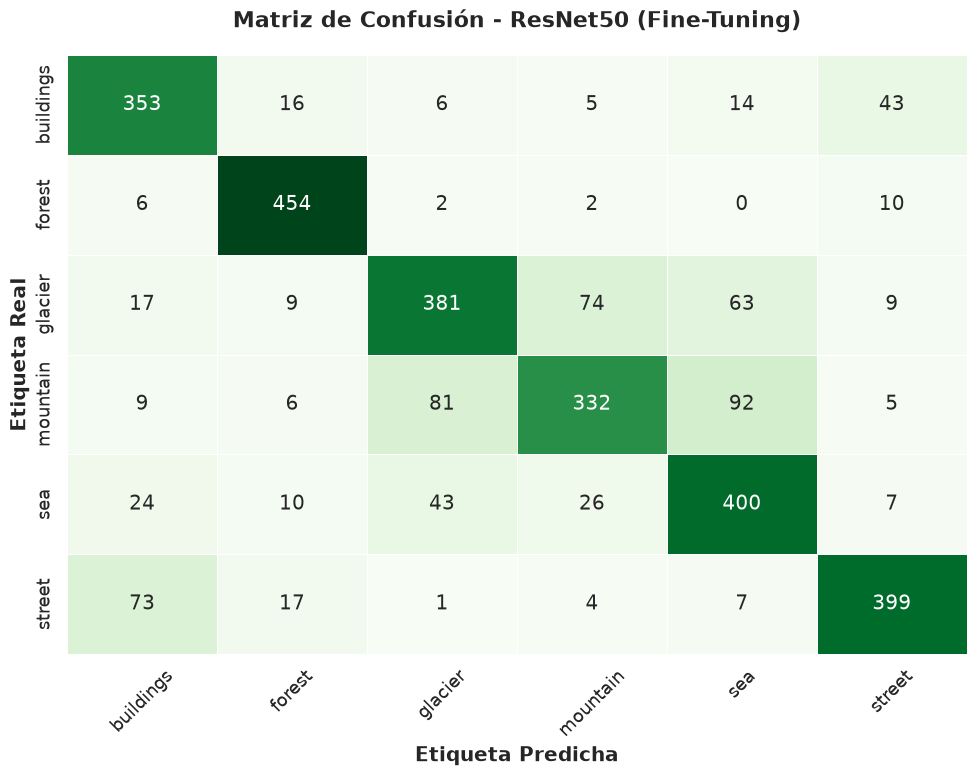

In [16]:
import numpy as np
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

print("Evaluando ResNet50 (Fine-Tuned) en el conjunto de prueba...")

# 1. Reiniciar generador
test_generator.reset()

# 2. Obtener predicciones
Y_pred_resnet = model_resnet_tl.predict(test_generator, verbose=1)
y_pred_resnet = np.argmax(Y_pred_resnet, axis=1)
y_true = test_generator.classes
nombres_clases = list(test_generator.class_indices.keys())

# 3. Reporte de Clasificación (Para tu Tabla 3)
print("\n" + "="*50)
print("REPORTE DE CLASIFICACIÓN - RESNET50 (FINE-TUNING)")
print("="*50)
print(classification_report(y_true, y_pred_resnet, target_names=nombres_clases, digits=4))

# 4. Matriz de Confusión
cm_resnet = confusion_matrix(y_true, y_pred_resnet)

plt.figure(figsize=(10, 8))
sns.set(font_scale=1.2)
sns.heatmap(
    cm_resnet, 
    annot=True, 
    fmt='d', 
    cmap='Greens', # Usamos verde para diferenciarla de VGG16 en tu artículo
    xticklabels=nombres_clases, 
    yticklabels=nombres_clases,
    linewidths=.5,
    cbar=False
)

plt.ylabel('Etiqueta Real', fontweight='bold')
plt.xlabel('Etiqueta Predicha', fontweight='bold')
plt.title('Matriz de Confusión - ResNet50 (Fine-Tuning)', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Resultados del modelo Preentrenado

In [17]:
import numpy as np
from sklearn.metrics import precision_recall_fscore_support, accuracy_score

print("Procesando métricas para la Tabla de Modelo Preentrenado (Fine-Tuning)...")

# 1. Obtener predicciones del modelo FINE-TUNING
test_generator.reset()
Y_pred_tl = model_resnet_tl.predict(test_generator, verbose=0)
y_pred_tl = np.argmax(Y_pred_tl, axis=1)
y_true = test_generator.classes

# 2. Calcular métricas
acc_test_tl = accuracy_score(y_true, y_pred_tl)
prec_tl, rec_tl, f1_tl, _ = precision_recall_fscore_support(y_true, y_pred_tl, average='macro')

# 3. Extraer el Accuracy de Entrenamiento y Validación de la mejor época del Fine-Tuning
best_epoch_tl = np.argmax(history_resnet_ft.history['val_accuracy'])
acc_train_tl = history_resnet_ft.history['accuracy'][best_epoch_tl]
acc_val_tl = history_resnet_ft.history['val_accuracy'][best_epoch_tl]
total_epochs_tl = len(history_resnet_ft.history['loss'])

# 4. Imprimir para la tabla
print("\n" + "="*70)
print("TABLA 1: Resumen de las métricas del modelo PREENTRENADO (Fine-Tuning)")
print("="*70)
print(f"Modelo                : ResNet50 (Fine-Tuning)")
print(f"Image Batch           : {test_generator.batch_size}") 
print(f"Epocas                : {total_epochs_tl} (Mejor época: {best_epoch_tl + 1})")
print(f"Optimizador           : Adam (lr=1e-5)")
print(f"Accuracy Entrenamiento: {acc_train_tl:.4f}")
print(f"Accuracy Validación   : {acc_val_tl:.4f}")
print(f"Accuracy Prueba       : {acc_test_tl:.4f}")
print(f"Precision (macro)     : {prec_tl:.4f}")
print(f"Recall (macro)        : {rec_tl:.4f}")
print(f"F1-score (macro)      : {f1_tl:.4f}")
print("="*70)

Procesando métricas para la Tabla de Modelo Preentrenado (Fine-Tuning)...

TABLA 1: Resumen de las métricas del modelo PREENTRENADO (Fine-Tuning)
Modelo                : ResNet50 (Fine-Tuning)
Image Batch           : 32
Epocas                : 15 (Mejor época: 11)
Optimizador           : Adam (lr=1e-5)
Accuracy Entrenamiento: 0.7425
Accuracy Validación   : 0.7730
Accuracy Prueba       : 0.7730
Precision (macro)     : 0.7746
Recall (macro)        : 0.7779
F1-score (macro)      : 0.7742
